In [119]:
import glob
import torch
import soxr
import numpy as np
import torch.nn.functional as F

from nnAudio.features import CQT
from src.utils import load_audio, speed_up, get_spectrum, get_fakeprints, get_freqs, get_freqs_mask


DEVICE = torch.device("cpu")

N_FFT = 1 << 14
SR = 44100
BINS_PER_OCTAVE = 96
AREA = 20
FREQ_RANGE = [200, 16000]
FMIN = 32.7
SHOW_AI = True

ai_dir = "/Users/emiledugelay/datasets/sunov5/"
human_dir = "/Users/emiledugelay/datasets/fma_small/"
data_dir = ai_dir if SHOW_AI else human_dir

hop_length = N_FFT // 2
fmax = SR / 2  # Maximum frequency that can be represented

freqs = get_freqs(n_fft=N_FFT, sr=SR, log=True, bins_per_octave=BINS_PER_OCTAVE, fmin=FMIN)
mask = get_freqs_mask(freqs, sr=SR, freq_range=FREQ_RANGE)
freqs = freqs.to(DEVICE)
freqs_crop = freqs[mask]
print(len(freqs))

cqt_transform = CQT(
    sr=SR,
    hop_length=hop_length,
    fmin=FMIN,
    fmax=fmax,
    bins_per_octave=BINS_PER_OCTAVE,
    output_format="Magnitude",
    verbose=False,
).to(DEVICE)



file_paths = glob.glob(f"{data_dir}/**/*.mp3", recursive=True)
audio_paths = np.random.choice(file_paths, size=2, replace=False)

waveforms = []
for path in audio_paths:
    waveform, sr = load_audio(path)
    if sr != SR:
        print(f"Resampling {path} from {sr} Hz to {SR} Hz")
        waveform = soxr.resample(waveform.T, sr, SR, quality="VHQ").T
        waveform = torch.from_numpy(waveform)
    waveform = waveform.mean(dim=0, keepdim=True)
    waveforms.append(waveform)

waveform1 = waveforms[0]
waveform2 = waveforms[1]
print(f"Loaded {audio_paths[0]} with shape {waveform1.shape} and sample rate {SR}")
print(f"Loaded {audio_paths[1]} with shape {waveform2.shape} and sample rate {SR}")

903


/Users/emiledugelay/Machine-Learning/deezer/robust-deepfake-detector/.venv/lib/python3.13/site-packages/nnAudio/utils.py:429: SyntaxWarning: If fmax is given, n_bins will be ignored
  warnings.warn("If fmax is given, n_bins will be ignored", SyntaxWarning)


Resampling /Users/emiledugelay/datasets/sunov5/b4c8751847eb502f9066b48254913eee6e369406486ed10b2dcda9a6b3e55d6f.mp3 from 48000 Hz to 44100 Hz
Resampling /Users/emiledugelay/datasets/sunov5/c532d230fb47d9b50519a7f66a1f0d6f3f0fcda6f45899ead7ee21e29dbdcec7.mp3 from 48000 Hz to 44100 Hz
Loaded /Users/emiledugelay/datasets/sunov5/b4c8751847eb502f9066b48254913eee6e369406486ed10b2dcda9a6b3e55d6f.mp3 with shape torch.Size([1, 6350399]) and sample rate 44100
Loaded /Users/emiledugelay/datasets/sunov5/c532d230fb47d9b50519a7f66a1f0d6f3f0fcda6f45899ead7ee21e29dbdcec7.mp3 with shape torch.Size([1, 8070299]) and sample rate 44100


In [128]:
SPEED_FACTOR = 1.12

su_waveform1 = speed_up(waveform1, sr=SR, speed_factor=SPEED_FACTOR)

spec1 = get_spectrum(cqt_transform, waveform1)
su_spec1 = get_spectrum(cqt_transform, su_waveform1)
spec2 = get_spectrum(cqt_transform, waveform2)

spec1 = spec1.mean(dim=-1)
su_spec1 = su_spec1.mean(dim=-1)
spec2 = spec2.mean(dim=-1)

fp1 = get_fakeprints(spec1, area=AREA)
su_fp1 = get_fakeprints(su_spec1, area=AREA)
fp2 = get_fakeprints(spec2, area=AREA)

fp1 = fp1[:, mask]
su_fp1 = su_fp1[:, mask]
fp2 = fp2[:, mask]

fp1 = torch.clip(fp1, None, 8.0)
su_fp1 = torch.clip(su_fp1, None, 8.0)
fp2 = torch.clip(fp2, None, 8.0)

fp1 = F.normalize(fp1, dim=-1)
su_fp1 = F.normalize(su_fp1, dim=-1)
fp2 = F.normalize(fp2, dim=-1)

fp1.shape, su_fp1.shape, fp2.shape

(torch.Size([1, 607]), torch.Size([1, 607]), torch.Size([1, 607]))

In [129]:
import torch

def shift_spectre(spectre, decalage, dim=1):
    """
    Décale un tenseur de spectre le long d'une dimension donnée.
    
    Args:
        spectre (torch.Tensor): Le tenseur à décaler, ex: de forme (B, F).
        decalage (int): Le nombre de bins de décalage. Positif vers la droite, négatif vers la gauche.
        dim (int): La dimension des fréquences (1 par défaut pour (B, F)).
    """
    # Si le décalage est de 0, on ne fait rien pour économiser du calcul
    if decalage == 0:
        return spectre
        
    # 1. Décalage circulaire avec torch.roll
    spectre_decale = torch.roll(spectre, shifts=decalage, dims=dim)
    
    # 2. Remplacement des valeurs qui ont fait le tour (Wrap-around) par 0
    if decalage > 0:
        # Les hautes fréquences sont revenues à gauche (au début) : on les met à zéro
        spectre_decale[:, :decalage] = 0.0
    elif decalage < 0:
        # Les basses fréquences sont passées à droite (à la fin) : on les met à zéro
        spectre_decale[:, decalage:] = 0.0
        
    return spectre_decale

Frequency scaling factors: [0.80524517 0.8110803  0.81695773 0.82287774 0.82884065 0.83484677
 0.84089642 0.8469899  0.85312754 0.85930965 0.86553656 0.8718086
 0.87812608 0.88448934 0.89089872 0.89735454 0.90385714 0.91040686
 0.91700404 0.92364903 0.93034217 0.93708382 0.94387431 0.95071402
 0.95760328 0.96454247 0.97153194 0.97857206 0.9856632  0.99280572
 1.         1.00724641 1.01454533 1.02189715 1.02930224 1.03676098
 1.04427378 1.05184102 1.05946309 1.0671404  1.07487334 1.08266232
 1.09050773 1.09841    1.10636953 1.11438674 1.12246205 1.13059587
 1.13878863 1.14704077 1.1553527  1.16372486 1.17215769 1.18065163
 1.18920712 1.1978246  1.20650453 1.21524736 1.22405354 1.23292354]
Applied bin shift for speed factor 1.12: 15.70 bins


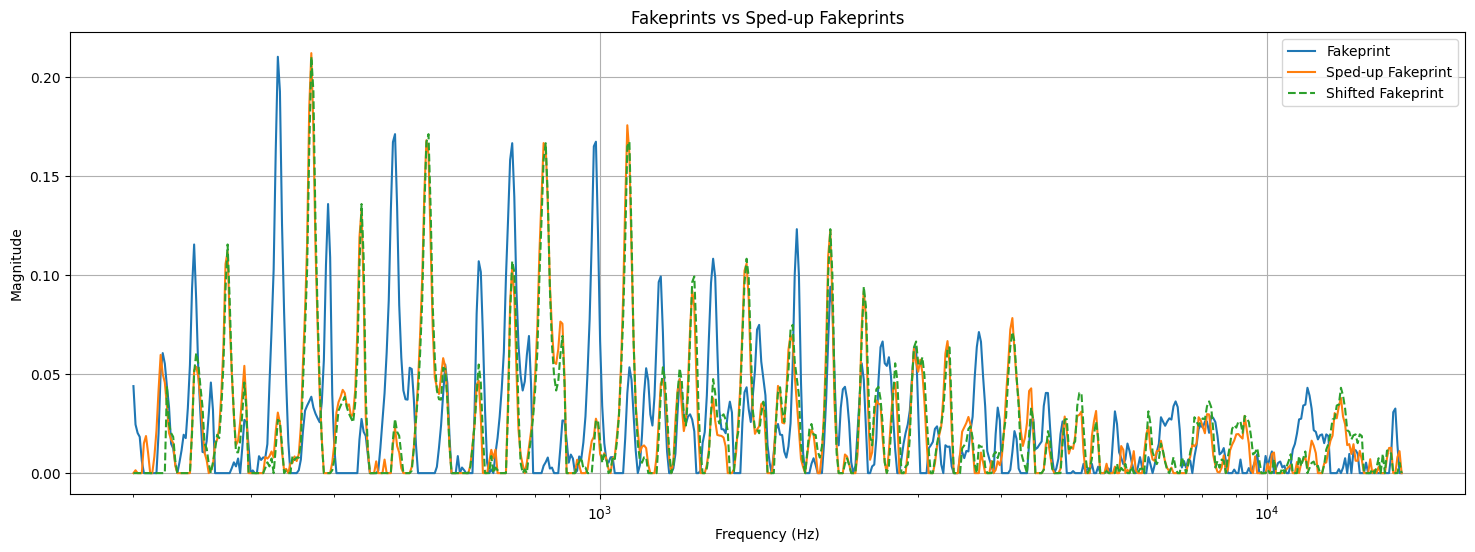

In [130]:
import matplotlib.pyplot as plt

bin_shifts = np.arange(-30, 30)  # Example bin shifts for 100 bins up and down
a = 2 ** (bin_shifts / BINS_PER_OCTAVE)  # Calculate the frequency scaling factor
print(f"Frequency scaling factors: {a}")

applied_bin_shift = BINS_PER_OCTAVE * np.log2(SPEED_FACTOR)  # Calculate the bin shift corresponding to the speed factor
print(f"Applied bin shift for speed factor {SPEED_FACTOR}: {applied_bin_shift:.2f} bins")

shifted_fp1 = shift_spectre(fp1, int(round(applied_bin_shift)), dim=1)

# plot fakeprints & sped up fakeprints
plt.figure(figsize=(18, 6))
plt.plot(freqs_crop, fp1[0].cpu(), label="Fakeprint")
plt.plot(freqs_crop, su_fp1[0].cpu(), label="Sped-up Fakeprint")
plt.plot(freqs_crop, shifted_fp1[0].cpu(), label="Shifted Fakeprint", linestyle="dashed")
plt.xscale("log")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("Fakeprints vs Sped-up Fakeprints")
plt.legend()
plt.grid()
plt.show()

argmax crosscorr: 319
predicted lag index: 319


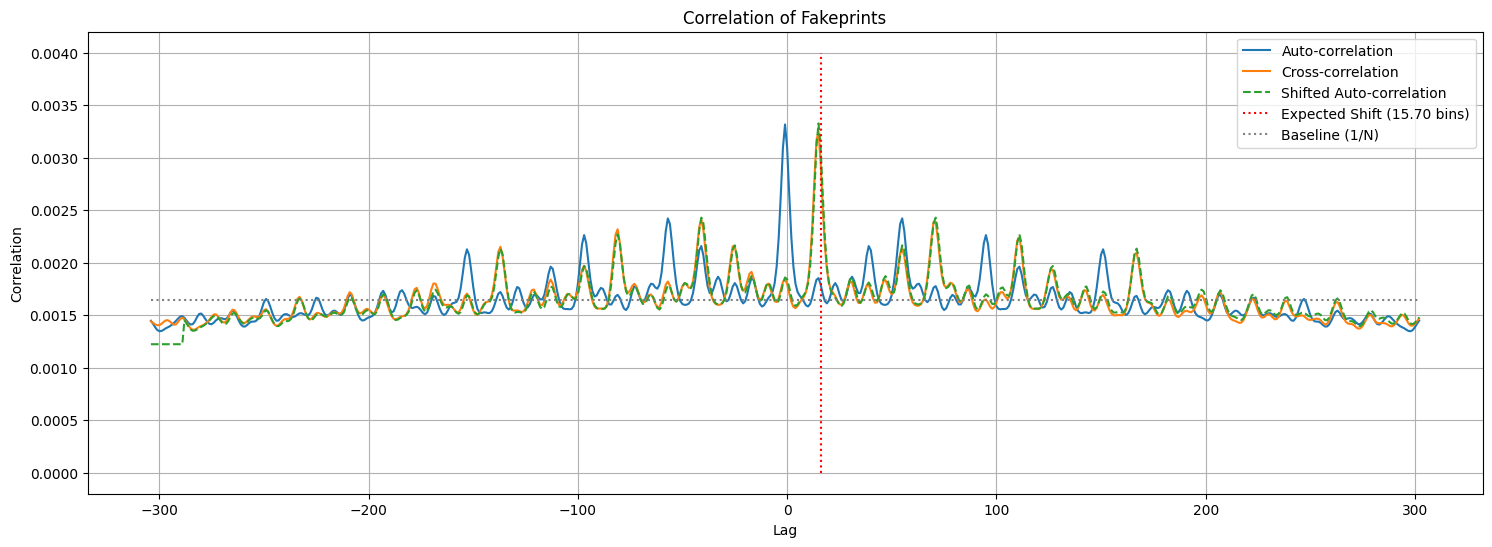

In [131]:
fp3 = torch.randn_like(fp1)  # Random fakeprint for testing
cross_corr = F.conv1d(fp1.unsqueeze(1), fp1.unsqueeze(1), padding="same").squeeze()
cross_corr_su = F.conv1d(su_fp1.unsqueeze(1), fp1.unsqueeze(1), padding="same").squeeze()

lags = np.arange(-len(fp1[0])//2 , len(fp1[0])//2)

shifted_cross_corr = shift_spectre(cross_corr.unsqueeze(0), int(round(applied_bin_shift)), dim=1).squeeze(0)

lag_index = len(fp1[0]) // 2 + int(round(applied_bin_shift))

print(f"argmax crosscorr: {torch.argmax(cross_corr_su).item()}")
print(f"predicted lag index: {lag_index}")

plt.figure(figsize=(18, 6))
plt.plot(lags, torch.softmax(cross_corr, dim=-1).numpy(), label="Auto-correlation")
plt.plot(lags, torch.softmax(cross_corr_su, dim=-1).numpy(), label="Cross-correlation")
plt.plot(lags, torch.softmax(shifted_cross_corr, dim=-1).numpy(), label="Shifted Auto-correlation", linestyle="dashed")
plt.vlines(int(round(applied_bin_shift)), ymin=0, ymax=0.004, color="red", linestyle="dotted", label=f"Expected Shift ({applied_bin_shift:.2f} bins)")
plt.hlines(1/len(fp1[0]), xmin=lags[0], xmax=lags[-1], color="gray", linestyle="dotted", label="Baseline (1/N)")
plt.xlabel("Lag")
plt.ylabel("Correlation")
plt.title("Correlation of Fakeprints")
plt.legend()
plt.grid()
plt.show()